In [6]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

print("PATH:", repr(os.getenv("MT5_PATH")))
print("Exists:", os.path.exists(os.getenv("MT5_PATH") or ""))

PATH: 'C:\\Program Files\\MetaTrader 5 EXNESS\\terminal64.exe'
Exists: True


In [1]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

import MetaTrader5 as mt5

LOGIN = int(os.getenv("MT5_LOGIN"))
PASSWORD = os.getenv("MT5_PASSWORD")
SERVER = os.getenv("MT5_SERVER")
MT5_PATH = os.getenv("MT5_PATH")

if not mt5.initialize(path=MT5_PATH, login=LOGIN, password=PASSWORD, server=SERVER):
    print("initialize failed:", mt5.last_error())
else:
    acc = mt5.account_info()
    print("Connected:", acc.login, "|", acc.server, "|", acc.balance, acc.currency)
    mt5.shutdown()

Connected: 477198031 | Exness-MT5Trial9 | 30000.0 KES


In [2]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

import MetaTrader5 as mt5
import pandas as pd

LOGIN = int(os.getenv("MT5_LOGIN"))
PASSWORD = os.getenv("MT5_PASSWORD")
SERVER = os.getenv("MT5_SERVER")
MT5_PATH = os.getenv("MT5_PATH")

SYMBOL = "EURUSDm"
TIMEFRAME = mt5.TIMEFRAME_H1
N_BARS = 10

if not mt5.initialize(path=MT5_PATH, login=LOGIN, password=PASSWORD, server=SERVER):
    print("initialize() failed:", mt5.last_error())
else:
    acc = mt5.account_info()
    print(f"Connected: #{acc.login} | {acc.server} | balance {acc.balance:.2f} {acc.currency}\n")

    if not mt5.symbol_select(SYMBOL, True):
        print(f"Symbol {SYMBOL!r} not found. Checking what's available...")
        matches = [s.name for s in mt5.symbols_get() if "EURUSD" in s.name.upper()]
        print("Available EURUSD symbols:", matches)
        mt5.shutdown()
    else:
        rates = mt5.copy_rates_from_pos(SYMBOL, TIMEFRAME, 0, N_BARS)
        mt5.shutdown()

        if rates is None or len(rates) == 0:
            print("No data returned:", mt5.last_error())
        else:
            df = pd.DataFrame(rates)
            df["time"] = pd.to_datetime(df["time"], unit="s")
            print(df[["time", "open", "high", "low", "close", "tick_volume", "spread"]])

Connected: #477198031 | Exness-MT5Trial9 | balance 30000.00 KES

                 time     open     high      low    close  tick_volume  spread
0 2026-09-22 14:00:00  1.14531  1.14548  1.14392  1.14426         2877       8
1 2026-09-22 15:00:00  1.14426  1.14437  1.14304  1.14311         2130       8
2 2026-09-22 16:00:00  1.14310  1.14384  1.14290  1.14367         1725       8
3 2026-09-22 17:00:00  1.14367  1.14417  1.14304  1.14390         1563       8
4 2026-09-22 18:00:00  1.14390  1.14432  1.14372  1.14417         1519       8
5 2026-09-22 19:00:00  1.14417  1.14546  1.14410  1.14475         1652       8
6 2026-09-22 20:00:00  1.14475  1.14509  1.14466  1.14473          658       8
7 2026-09-22 21:00:00  1.14473  1.14492  1.14440  1.14487          480      13
8 2026-09-22 22:00:00  1.14489  1.14494  1.14455  1.14463          462       8
9 2026-09-22 23:00:00  1.14462  1.14475  1.14453  1.14474          279       8


In [3]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

import MetaTrader5 as mt5
import pandas as pd

LOGIN    = int(os.getenv("MT5_LOGIN"))
PASSWORD = os.getenv("MT5_PASSWORD")
SERVER   = os.getenv("MT5_SERVER")
MT5_PATH = os.getenv("MT5_PATH")

SYMBOL    = "EURUSDm"
TIMEFRAME = mt5.TIMEFRAME_H1
N_BARS    = 1000

if not mt5.initialize(path=MT5_PATH, login=LOGIN, password=PASSWORD, server=SERVER):
    raise RuntimeError(f"initialize failed: {mt5.last_error()}")

mt5.symbol_select(SYMBOL, True)
rates = mt5.copy_rates_from_pos(SYMBOL, TIMEFRAME, 0, N_BARS)
mt5.shutdown()

if rates is None or len(rates) == 0:
    raise RuntimeError(f"No data returned: {mt5.last_error()}")

df = pd.DataFrame(rates)
df["time"] = pd.to_datetime(df["time"], unit="s")
df = df.set_index("time").sort_index()
df = df[["open", "high", "low", "close", "tick_volume", "spread"]]

df["ema20"] = df["close"].ewm(span=20, adjust=False).mean()
df["ema50"] = df["close"].ewm(span=50, adjust=False).mean()

delta    = df["close"].diff()
gain     = delta.clip(lower=0)
loss     = -delta.clip(upper=0)
avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()
rs       = avg_gain / avg_loss
df["rsi14"] = 100 - (100 / (1 + rs))

df.to_csv("eurusd_h1.csv")
print(f"Saved {len(df)} rows to eurusd_h1.csv")
print(f"From {df.index[0]} to {df.index[-1]}\n")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)
print(df.tail(10).round(5))

Saved 1000 rows to eurusd_h1.csv
From 2026-07-28 07:00:00 to 2026-09-23 22:00:00

                        open     high      low    close  tick_volume  spread    ema20    ema50     rsi14
time                                                                                                    
2026-09-23 13:00:00  1.14079  1.14154  1.13905  1.13967         3608       8  1.14250  1.14435  23.49600
2026-09-23 14:00:00  1.13969  1.14049  1.13832  1.14017         4552       8  1.14228  1.14418  29.05345
2026-09-23 15:00:00  1.14019  1.14024  1.13872  1.13928         2568       8  1.14199  1.14399  25.50225
2026-09-23 16:00:00  1.13926  1.13952  1.13754  1.13780         2280       8  1.14159  1.14375  20.92246
2026-09-23 17:00:00  1.13779  1.13925  1.13698  1.13915         3395       8  1.14136  1.14357  32.78065
2026-09-23 18:00:00  1.13915  1.13933  1.13801  1.13866         1702       8  1.14110  1.14338  30.96559
2026-09-23 19:00:00  1.13867  1.13886  1.13822  1.13839         1467       8  

In [4]:
print("Shape:", df.shape)
print("Monotonic index:", df.index.is_monotonic_increasing)
print("NaN counts:")
print(df[["close", "ema20", "ema50", "rsi14"]].isna().sum())
print("\nRSI range:", df["rsi14"].min().round(2), "to", df["rsi14"].max().round(2))
print("EMA20 vs EMA50 latest:", df["ema20"].iloc[-1].round(5), "vs", df["ema50"].iloc[-1].round(5))

Shape: (1000, 9)
Monotonic index: True
NaN counts:
close    0
ema20    0
ema50    0
rsi14    1
dtype: int64

RSI range: 17.1 to 100.0
EMA20 vs EMA50 latest: 1.14017 vs 1.14262


In [5]:
import numpy as np
import pandas as pd

# reload from CSV so we don't touch MT5 in this cell
df = pd.read_csv("eurusd_h1.csv", parse_dates=["time"], index_col="time")

# --- 1. generate crossover signals ---
df["ema_cross_up"]   = (df["ema20"] > df["ema50"]) & (df["ema20"].shift(1) <= df["ema50"].shift(1))
df["ema_cross_down"] = (df["ema20"] < df["ema50"]) & (df["ema20"].shift(1) >= df["ema50"].shift(1))

# --- 2. filter with RSI ---
df["long_signal"]  = df["ema_cross_up"]   & (df["rsi14"] > 50)
df["short_signal"] = df["ema_cross_down"] & (df["rsi14"] < 50)

# --- 3. build position series (+1 = long, -1 = short, 0 = flat) ---
position = pd.Series(0, index=df.index, dtype=int)
pos = 0
for i in range(len(df)):
    if df["long_signal"].iloc[i]:
        pos = 1
    elif df["short_signal"].iloc[i]:
        pos = -1
    position.iloc[i] = pos

df["position"] = position

# --- 4. backtest: 1-bar-ahead returns ---
df["return"]  = df["close"].pct_change()
df["strategy"] = df["position"].shift(1) * df["return"]   # shift = enter on next bar

# --- 5. equity curve ---
df["equity"] = (1 + df["strategy"]).cumprod()

# --- metrics ---
total_return  = (df["equity"].iloc[-1] - 1) * 100
n_trades      = (df["position"].diff().abs() > 0).sum()
wins          = (df["strategy"] > 0).sum()
losses        = (df["strategy"] < 0).sum()
win_rate      = wins / (wins + losses) * 100 if (wins + losses) else 0
drawdown      = (df["equity"] / df["equity"].cummax() - 1).min() * 100

print(f"Total return : {total_return:+.2f}%")
print(f"Trades       : {n_trades}")
print(f"Win rate     : {win_rate:.1f}%")
print(f"Max drawdown : {drawdown:.2f}%")
print(f"Final equity : {df['equity'].iloc[-1]:.4f}")

print("\nLast 10 bars:")
print(df[["close", "ema20", "ema50", "rsi14", "position", "strategy", "equity"]].tail(10).round(5))

Total return : +4.27%
Trades       : 12
Win rate     : 52.5%
Max drawdown : -0.89%
Final equity : 1.0427

Last 10 bars:
                       close    ema20    ema50     rsi14  position  strategy   equity
time                                                                                 
2026-09-23 13:00:00  1.13967  1.14250  1.14435  23.49600        -1   0.00099  1.04160
2026-09-23 14:00:00  1.14017  1.14228  1.14418  29.05345        -1  -0.00044  1.04115
2026-09-23 15:00:00  1.13928  1.14199  1.14399  25.50225        -1   0.00078  1.04196
2026-09-23 16:00:00  1.13780  1.14159  1.14375  20.92246        -1   0.00130  1.04331
2026-09-23 17:00:00  1.13915  1.14136  1.14357  32.78065        -1  -0.00119  1.04207
2026-09-23 18:00:00  1.13866  1.14110  1.14338  30.96559        -1   0.00043  1.04252
2026-09-23 19:00:00  1.13839  1.14084  1.14318  29.98052        -1   0.00024  1.04277
2026-09-23 20:00:00  1.13826  1.14060  1.14299  29.49402        -1   0.00011  1.04289
2026-09-23 21:00:00 

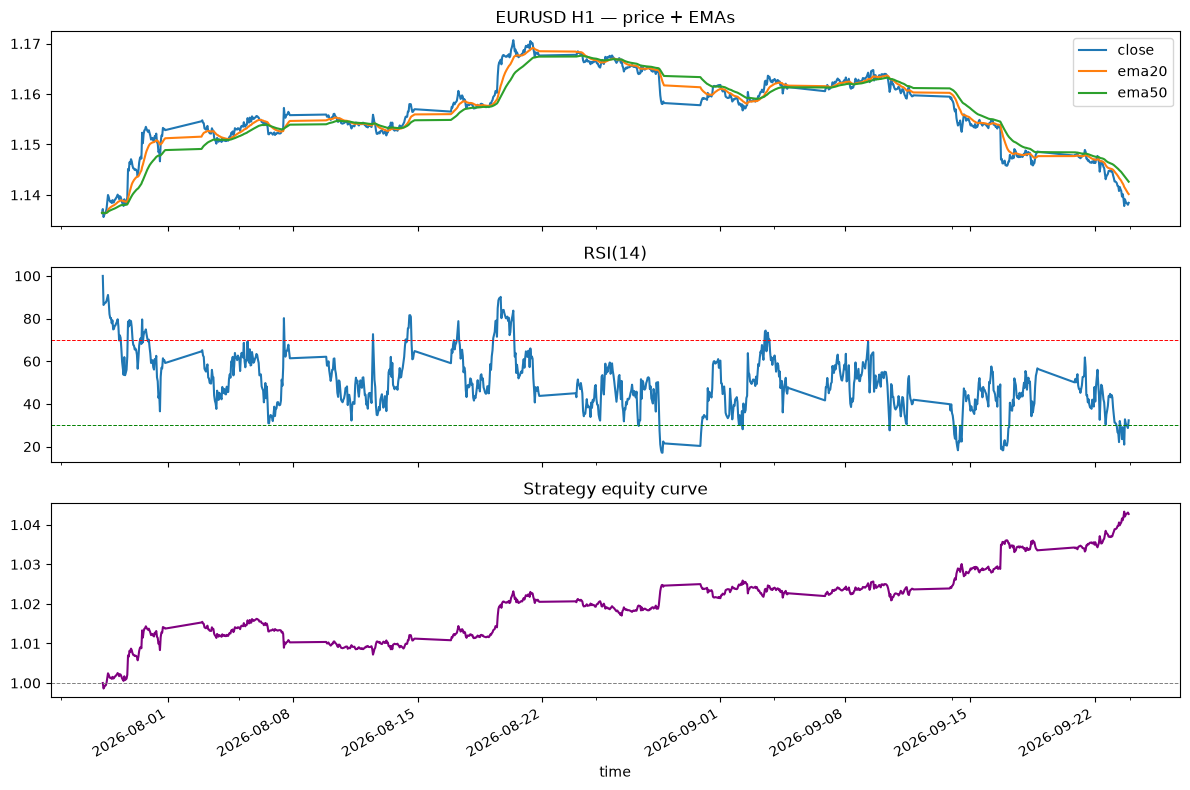

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

df[["close", "ema20", "ema50"]].plot(ax=axes[0], title="EURUSD H1 — price + EMAs")
df["rsi14"].plot(ax=axes[1], title="RSI(14)")
axes[1].axhline(70, color="r", linestyle="--", linewidth=0.7)
axes[1].axhline(30, color="g", linestyle="--", linewidth=0.7)

df["equity"].plot(ax=axes[2], title="Strategy equity curve", color="purple")
axes[2].axhline(1.0, color="gray", linestyle="--", linewidth=0.7)

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("eurusd_h1.csv", parse_dates=["time"], index_col="time")

# --- rebuild signals (same as Stage 3) ---
df["ema_cross_up"]   = (df["ema20"] > df["ema50"]) & (df["ema20"].shift(1) <= df["ema50"].shift(1))
df["ema_cross_down"] = (df["ema20"] < df["ema50"]) & (df["ema20"].shift(1) >= df["ema50"].shift(1))
df["long_signal"]    = df["ema_cross_up"]   & (df["rsi14"] > 50)
df["short_signal"]   = df["ema_cross_down"] & (df["rsi14"] < 50)

position = pd.Series(0, index=df.index, dtype=int)
pos = 0
for i in range(len(df)):
    if df["long_signal"].iloc[i]:   pos = 1
    elif df["short_signal"].iloc[i]: pos = -1
    position.iloc[i] = pos
df["position"] = position

# --- returns and costs ---
SPREAD_COST = 0.00008   # 8 points on EURUSD = 0.00008
df["return"] = df["close"].pct_change()
df["trade"]  = df["position"].diff().fillna(0) != 0
df["cost"]   = np.where(df["trade"], SPREAD_COST, 0)
df["strategy"] = df["position"].shift(1) * df["return"] - df["cost"]
df["equity"]   = (1 + df["strategy"]).cumprod()

# --- trade-level metrics ---
trades = []
entry_price = None
entry_pos   = 0
for i, (t, row) in enumerate(df.iterrows()):
    if row["trade"]:
        if entry_price is not None:
            pnl = (row["close"] - entry_price) / entry_price * entry_pos
            trades.append(pnl)
        entry_price = row["close"]
        entry_pos   = row["position"]
    elif i == len(df) - 1 and entry_price is not None:
        pnl = (row["close"] - entry_price) / entry_price * entry_pos
        trades.append(pnl)

trades = np.array(trades)
n_trades      = len(trades)
wins          = (trades > 0).sum()
losses        = (trades < 0).sum()
win_rate      = wins / n_trades * 100 if n_trades else 0
avg_win       = trades[trades > 0].mean() * 100 if wins else 0
avg_loss      = trades[trades < 0].mean() * 100 if losses else 0
profit_factor = trades[trades > 0].sum() / abs(trades[trades < 0].sum()) if losses else np.inf
total_return  = (df["equity"].iloc[-1] - 1) * 100
sharpe        = df["strategy"].mean() / df["strategy"].std() * np.sqrt(24*252) if df["strategy"].std() else 0
drawdown      = (df["equity"] / df["equity"].cummax() - 1).min() * 100

print(f"Total return   : {total_return:+.2f}%")
print(f"Trades         : {n_trades}")
print(f"Win rate       : {win_rate:.1f}%   ({wins}W / {losses}L)")
print(f"Avg win        : {avg_win:+.3f}%")
print(f"Avg loss       : {avg_loss:+.3f}%")
print(f"Profit factor  : {profit_factor:.2f}")
print(f"Sharpe (ann.)  : {sharpe:.2f}")
print(f"Max drawdown   : {drawdown:.2f}%")
print(f"Final equity   : {df['equity'].iloc[-1]:.4f}")

print("\nAll trades (% P&L):")
for i, t in enumerate(trades, 1):
    print(f"  {i:2d}: {t*100:+.3f}%")

Total return   : +4.17%
Trades         : 12
Win rate       : 41.7%   (5W / 7L)
Avg win        : +0.973%
Avg loss       : -0.096%
Profit factor  : 7.24
Sharpe (ann.)  : 5.44
Max drawdown   : -0.91%
Final equity   : 1.0417

All trades (% P&L):
   1: +1.327%
   2: -0.300%
   3: -0.144%
   4: -0.003%
   5: +1.074%
   6: -0.055%
   7: -0.065%
   8: -0.060%
   9: -0.044%
  10: +0.490%
  11: +0.021%
  12: +1.953%


In [10]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

import MetaTrader5 as mt5
import pandas as pd

LOGIN    = int(os.getenv("MT5_LOGIN"))
PASSWORD = os.getenv("MT5_PASSWORD")
SERVER   = os.getenv("MT5_SERVER")
MT5_PATH = os.getenv("MT5_PATH")

SYMBOL    = "EURUSDm"
TIMEFRAME = mt5.TIMEFRAME_H1
N_BARS    = 5000

if not mt5.initialize(path=MT5_PATH, login=LOGIN, password=PASSWORD, server=SERVER):
    raise RuntimeError(mt5.last_error())
mt5.symbol_select(SYMBOL, True)
rates = mt5.copy_rates_from_pos(SYMBOL, TIMEFRAME, 0, N_BARS)
mt5.shutdown()

df = pd.DataFrame(rates)
df["time"] = pd.to_datetime(df["time"], unit="s")
df = df.set_index("time").sort_index()[["open","high","low","close","tick_volume","spread"]]

df["ema20"] = df["close"].ewm(span=20, adjust=False).mean()
df["ema50"] = df["close"].ewm(span=50, adjust=False).mean()

delta    = df["close"].diff()
gain     = delta.clip(lower=0)
loss     = -delta.clip(upper=0)
df["rsi14"] = 100 - (100 / (1 + gain.ewm(alpha=1/14, adjust=False).mean()
                              / loss.ewm(alpha=1/14, adjust=False).mean()))

df.to_csv("eurusd_h1_5k.csv")
print(f"Saved {len(df)} rows: {df.index[0]} → {df.index[-1]}")

Saved 5000 rows: 2025-12-03 16:00:00 → 2026-09-23 22:00:00


In [11]:
def backtest(df_in, spread_cost=0.00008, slippage=0.00002):
    d = df_in.copy()
    d["cross_up"]   = (d["ema20"] > d["ema50"]) & (d["ema20"].shift(1) <= d["ema50"].shift(1))
    d["cross_down"] = (d["ema20"] < d["ema50"]) & (d["ema20"].shift(1) >= d["ema50"].shift(1))
    d["long"]  = d["cross_up"]   & (d["rsi14"] > 50)
    d["short"] = d["cross_down"] & (d["rsi14"] < 50)

    pos = 0
    positions = []
    for i in range(len(d)):
        if d["long"].iloc[i]:   pos = 1
        elif d["short"].iloc[i]: pos = -1
        positions.append(pos)
    d["position"] = positions

    d["ret"]   = d["close"].pct_change()
    d["trade"] = d["position"].diff().fillna(0) != 0
    cost = (spread_cost + slippage) * d["trade"]
    d["strategy"] = d["position"].shift(1) * d["ret"] - cost
    d["equity"]   = (1 + d["strategy"]).cumprod()

    return d


def summarize(name, d):
    ret = (d["equity"].iloc[-1] - 1) * 100
    dd  = (d["equity"] / d["equity"].cummax() - 1).min() * 100
    n   = (d["position"].diff().fillna(0) != 0).sum()
    shp = (d["strategy"].mean() / d["strategy"].std() * (24*252)**0.5) if d["strategy"].std() else 0
    print(f"{name:20s}  return {ret:+6.2f}%   trades {n:3d}   maxDD {dd:+6.2f}%   Sharpe {shp:5.2f}")


# Load the 5k dataset
df5 = pd.read_csv("eurusd_h1_5k.csv", parse_dates=["time"], index_col="time")

# Split: oldest 70% = in-sample, newest 30% = out-of-sample
split = int(len(df5) * 0.7)
train = df5.iloc[:split]
test  = df5.iloc[split:]

print(f"Train: {train.index[0]} → {train.index[-1]}  ({len(train)} bars)")
print(f"Test : {test.index[0]} → {test.index[-1]}  ({len(test)} bars)\n")

summarize("In-sample (70%)",  backtest(train))
summarize("Out-of-sample (30%)", backtest(test))
summarize("Full 5k", backtest(df5))

Train: 2025-12-03 16:00:00 → 2026-06-29 10:00:00  (3500 bars)
Test : 2026-06-29 11:00:00 → 2026-09-23 22:00:00  (1500 bars)

In-sample (70%)       return  -1.40%   trades  61   maxDD  -7.32%   Sharpe -0.37
Out-of-sample (30%)   return  +0.98%   trades  25   maxDD  -3.17%   Sharpe  0.90
Full 5k               return  -0.59%   trades  86   maxDD  -9.20%   Sharpe -0.10
